# Imports

In [1]:
import requests
import time
import pandas as pd
import xml.etree.ElementTree as ET
from collections import defaultdict
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents
import seaborn as sns
from collections import Counter
import json
from matplotlib.ticker import ScalarFormatter
from scipy.signal import savgol_filter
import warnings
warnings.filterwarnings('ignore')

In [2]:
import sys
import platform
import pkg_resources

# Python version
print("Python version:", sys.version)

# OS info
print("OS:", platform.system(), platform.release())

# Installed packages & versions
for package in ["pandas", "matplotlib", "seaborn", "numpy", "requests", 'upsetplot', 'scipy']:
    print(f"{package} version:", pkg_resources.get_distribution(package).version)

Python version: 3.14.3 (v3.14.3:323c59a5e34, Feb  3 2026, 11:41:37) [Clang 16.0.0 (clang-1600.0.26.6)]
OS: Darwin 25.4.0
pandas version: 3.0.1
matplotlib version: 3.10.8
seaborn version: 0.13.2
numpy version: 2.3.5
requests version: 2.32.5
upsetplot version: 0.10.dev1
scipy version: 1.17.1


# Collect data

## Define search terms

In [3]:
# Define search terms for different omics categories
# (pubmed query terms not case-sensitive -> this is ok)

genomics_terms = [
    "genomics",
    "genome sequencing",
    "whole genome",
    "exome sequencing",
    "whole exome sequencing"
    "genetic profiling",
    "genetics",
    "genome-wide association study",
    "pharmacogenomic testing",
    "pharmacogenomic variants",
    "whole genome sequencing",
    "whole-genome sequencing",
    "genetic polymorphisms",
    "genetic polymorphism",
    "genetic testing",
    "genetic markers",
    "genetic variation",
    "genetic association studies",
    "cytogenetic analysis",
    "cytogenetics",
    "single-nucleotide polymorphism",
    "molecular genetics",
    "genetic heterogeneity",
    "pharmacogenetics",
    "genetic translocation",
    "genetic predisposition to disease",
    "genetic vectors",
    "genetic therapy",
    "genetic engineering",
    "dna mutational analysis",
    "dna sequencing",
    "sequence analysis, dna",
    "translocation",
    "high-throughput nucleotide sequencing",
    "exome sequencing"
    "epigenesis, genetic"
    "genotype",
    "genome, human",
    "long-read genomic sequencing",
    "long-read",
    "short-read"
]

transcriptomics_terms = [
    "transcriptomics",
    "rna sequencing",
    "rna-seq",
    "rna-sequencing",
    "gene expression profiling",
    "gene expression",
    "mRNA profiling",
    "transcript analysis",
    "alternative splicing",
    "rna sequence analysis",
    "sequence analysis, rna",
    "messenger rna",
    "transcriptome",
    "transcription",
    "transcription, genetic",
    "gene expression regulation",
    "gene expression regulation, leukemic"
    "gene expression regulation, neoplastic",
    "single-cell gene expression analysis",
    "single-cell transcriptomics"
    "single cell transcriptome sequencing",
    "single-cell rna sequencing",
    "spatial rna expression analysis",
    "scrna-seq",
    "gene expression analysis",
    "gene expression profile",
    "differential gene expression",
    "differential expression",
    "gene expression profiling (gep)",
    "gene expression signature",
    "ectopic gene expression",
    "microarray expression analysis",
    "expression",
    "expression microarray",
    "gene co-expression networks",
    "transcriptomic profiling",
    "whole transcriptome sequencing",
    "whole-transcriptome sequencing",
    "transcriptome sequencing",
    "gene transcription",
    "transcriptional activation",
    "reverse transcriptase polymerase chain reaction",
    "bulk rna-seq",
    "targeted rna sequencing",
]

epigenomics_terms = [
    "epigenome",
    "epigenomics",
    "methylation",
    "dna methylation",
    "dna demethylation",
    "dna hypermethylation",
    "histone modification",
    "histone modifications",
    "histone methylation",
    "promoter methylation",
    "epigenetics",
    "epigenetic",
    "chromatin profiling",
    "epigenetic profiling",
    "epigenetic regulation",
    "chip-seq",
    "chromatin immunoprecipitation sequencing",
    "chromatin accessibility",
    "heterochromatin",
    "atac-seq",
    "scatac-seq",
    "hi-c sequencing",
    "bisulphite amplicon sequencing",
    "chromatin remodeling",
    "chromatin",
    "chromatin state",
    "chromatin topology",
    "chromatin assembly and disassembly",
    "chromatin architecture",
]

proteomics_terms = [
    "proteome",
    "proteomic",
    "proteomics",
    "quantitative proteomics",
    "serological proteome analysis",
    "protein array analysis",
    "protein profiling",
    "mass spectrometry",
    "protein expression",
    "proximity extension assay",
    "proteomic profiling",
    "protein analysis",
    "proteomics",
    "olink",
    "olink proteomics",
    "somascan",
]

metabolomics_terms = [
    "metabolomics",
    "metabolome",
    "metabolic profiling",
    "metabolomic profiling",
    "lipid profile",
    "lipid metabolism",
    "lipidomics",
    "metabolite analysis",
    "metabolic analysis",
    "small molecule profiling",
    "small molecules",
    "chromatography, liquid",
    "tandem mass spectrometry",
    "spectrometry, mass, electrospray ionization",
    "lc-esi-ms/ms",
    "liquid chromatography-mass spectrometry",
    "chromatography, high pressure liquid",
    "liquid chromatography-tandem mass spectrometry",
    "plasma metabolites",
    "untargeted metabolomics",
    "untargeted chiral metabolomics",
]

multiomics_terms = [
    "multiomics",
    "multi-omics",
    "integrative omics",
    "systems biology",
    "multi-omics analysis",
    "single-cell multiomics",
    "single-cell multiome",
]

In [4]:
# save omics keywords into a table

df_keywords = pd.DataFrame([genomics_terms, transcriptomics_terms, epigenomics_terms, proteomics_terms, metabolomics_terms, multiomics_terms]).T
df_keywords.columns = ['genomics', 'transcriptomics', 'epigenomics', 'proteomics', 'metabolomics', 'multiomics']

df_keywords.to_csv('tables/omics_keywords.csv', index=False)
print("✓ Keywords saved to 'omics_keywords.csv'")


✓ Keywords saved to 'omics_keywords.csv'


## PubMed search

In [5]:
class PubMedSearcher:
    def __init__(self):
        self.base_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/"
        self.search_url = self.base_url + "esearch.fcgi"
        
    def search_pubmed_by_year(self, query, year):
        """
        Search PubMed for papers matching the query for a specific year
        """
        # Construct the full query with specific year
        date_range = f"{year}[PDAT]:{year}[PDAT]"
        full_query = f"({query}) AND ({date_range})"
        
        params = {
            'db': 'pubmed',
            'term': full_query,
            'retmax': 10000,  # We want every hit
            'retmode': 'xml'
        }
        
        try:
            response = requests.get(self.search_url, params=params)
            response.raise_for_status()
            
            # Parse XML response
            root = ET.fromstring(response.content)

            ids = [elem.text for elem in root.findall('.//Id')]

            return ids
            
        except requests.exceptions.RequestException as e:
            print(f"Error searching PubMed for year {year}: {e}")
            return 0
        except Exception as e:
            print(f"Error parsing results for year {year}: {e}")
            return 0

In [ ]:
searcher = PubMedSearcher()

# ensure no info from citations leaking in
base_terms_ALL = [
    '"Acute Lymphoblastic Leukemia"[mh]',
    '"Precursor Cell Lymphoblastic Leukemia-Lymphoma"[mh]',
    '"acute lymphoblastic leukemia"[tiab]'
]
base_terms_ALL = " OR ".join(base_terms_ALL)
base_terms_pediatric = 'pediatric[tiab] OR paediatric[tiab] OR child*[tiab] OR Child[mh]'
base_query = f'({base_terms_ALL}) AND ({base_terms_pediatric})'
# !FILTER THE BASE SEARCH:
base_query = f'({base_query}) NOT (Review[pt] OR "Case Reports"[pt] OR "Systematic Review"[pt])' # publication type = Review, Case reports
base_query = f'{base_query} NOT (Adult[ti] OR Adult[mh] OR "young adult"[mh])' # "Adult" in title or mesh terms
base_query = f'{base_query} NOT "bioRxiv : the preprint server for biology"[ta]' # remove preprints (one of the issues: same paper appearing in preprint vs when published)

categories = {
    "Genomics": genomics_terms,
    "Transcriptomics": transcriptomics_terms,
    "Epigenomics": epigenomics_terms,
    "Proteomics": proteomics_terms,
    "Metabolomics": metabolomics_terms,
    "Multiomics": multiomics_terms,
}

def or_group(words):
    return "(" + " OR ".join(f'"{w}"' if " " in w else w for w in words) + ")"

category_queries = {
    k: f"{base_query} AND {or_group(v)}"
    for k, v in categories.items()
}

# Store results
yearly_ids = defaultdict(lambda: defaultdict(str))

print("Starting PubMed data collection...")
print("="*60)

# Search all papers for each category
for i, (category, query) in enumerate(category_queries.items(), 1):
    print(f"\n[{i}/{len(category_queries)}] Collecting data for {category}...")
    print(f"Query: {query}")
    
    # Search for each year
    for year in range(2000, 2026):
        print(f'Collecting for year {year} ...')

        yearly_idlist = searcher.search_pubmed_by_year(query, year)
        yearly_ids[year][category] = yearly_idlist
        
        # Small delay to be respectful
        time.sleep(0.3)
    
    # Longer delay between categories
    time.sleep(1)

print(f'\nSaving raw collected data')
with open("tables/yearly_ids.json", "w") as f:
    json.dump(yearly_ids, f)

print(f'\nData collection complete!')
print(f'OBS: yearly_ids.json contains several non-article elements (PubMedBookArticle) because of esearch specifics. Will be REMOVED from all further steps')


Starting PubMed data collection...

[1/6] Collecting data for Genomics...
Query: (("Acute Lymphoblastic Leukemia"[mh] OR "Precursor Cell Lymphoblastic Leukemia-Lymphoma"[mh] OR "acute lymphoblastic leukemia"[tiab]) AND (pediatric[tiab] OR paediatric[tiab] OR child*[tiab] OR Child[mh])) NOT (Review[pt] OR "Case Reports"[pt] OR "Systematic Review"[pt]) NOT (Adult[ti] OR Adult[mh] OR "young adult"[mh]) NOT "bioRxiv : the preprint server for biology"[ta] AND (genomics OR "genome sequencing" OR "whole genome" OR "exome sequencing" OR "whole exome sequencinggenetic profiling" OR genetics OR "genome-wide association study" OR "pharmacogenomic testing" OR "pharmacogenomic variants" OR "whole genome sequencing" OR "whole-genome sequencing" OR "genetic polymorphisms" OR "genetic polymorphism" OR "genetic testing" OR "genetic markers" OR "genetic variation" OR "genetic association studies" OR "cytogenetic analysis" OR cytogenetics OR "single-nucleotide polymorphism" OR "molecular genetics" OR "ge

# Make a summary database

In [7]:
# load raw collected data
with open("tables/yearly_ids.json", "r") as f:
    yearly_ids = json.load(f)

# long table
rows = []
for year, omics_dict in yearly_ids.items():
    for omics_category, pubmed_ids in omics_dict.items():
        for pubmed_id in pubmed_ids:
            rows.append({
                "pmid": pubmed_id,
                "omics_category": omics_category,
                "year": year
            })

df = pd.DataFrame(rows)
# change to wide (bool for each category)
categories = [
    "Genomics", "Transcriptomics", "Epigenomics",
    "Proteomics", "Metabolomics", "Multiomics"
]

# one year per pubmed id
year_lookup = df.groupby("pmid")["year"].first()
df = (
    df.assign(value=True)
      .pivot_table(
          index="pmid",
          columns="omics_category",
          values="value",
          aggfunc="any",
          fill_value=False
      )
      .reindex(columns=categories, fill_value=False)
)
df.columns.name = None
# add year back as first column
df.insert(0, "year", year_lookup)


## Pubmed fetch metadata

In [8]:
# previous pubmed search uses esearch = only returns IDs
# now we need metadata = another function (efetch) = run pubmed API again

pmids = df.index.tolist()

bad_article_pmids = []

fetch_url = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi"

records = []

batch_size = 200

for i in range(0, len(pmids), batch_size):

    print(f'looking up paper {i} out of {len(pmids)}')

    batch = pmids[i:i+batch_size]

    params = {
        "db": "pubmed",
        "id": ",".join(batch),
        "retmode": "xml"
    }

    response = requests.get(fetch_url, params=params)
    response.raise_for_status()

    root = ET.fromstring(response.content)

    # collect pmids of papers to REMOVE
    # (removing from plotting later)
    for bad_article in root.findall(".//PubmedBookArticle"):
        bad_article_pmids.append(bad_article.findtext(".//PMID"))
    
    # collect metadata
    for article in root.findall(".//PubmedArticle"):

        pmid = article.findtext(".//PMID")
        
        if pmid not in bad_article_pmids:
            title = article.findtext(".//ArticleTitle")
            journal = article.findtext(".//Journal/Title")

            # DOI
            doi = None
            for x in article.findall(".//ArticleId"):
                if x.attrib.get("IdType") == "doi":
                    doi = x.text
                    break

            # Authors
            authors = []
            for a in article.findall(".//Author"):
                last = a.findtext("LastName")
                fore = a.findtext("ForeName")
                if last and fore:
                    authors.append(f"{fore} {last}")

            records.append({
                "pmid": pmid,
                "title": title,
                "journal": journal,
                "doi": doi,
                "authors": authors
            })

meta = pd.DataFrame(records)

looking up paper 0 out of 5832
looking up paper 200 out of 5832
looking up paper 400 out of 5832
looking up paper 600 out of 5832
looking up paper 800 out of 5832
looking up paper 1000 out of 5832
looking up paper 1200 out of 5832
looking up paper 1400 out of 5832
looking up paper 1600 out of 5832
looking up paper 1800 out of 5832
looking up paper 2000 out of 5832
looking up paper 2200 out of 5832
looking up paper 2400 out of 5832
looking up paper 2600 out of 5832
looking up paper 2800 out of 5832
looking up paper 3000 out of 5832
looking up paper 3200 out of 5832
looking up paper 3400 out of 5832
looking up paper 3600 out of 5832
looking up paper 3800 out of 5832
looking up paper 4000 out of 5832
looking up paper 4200 out of 5832
looking up paper 4400 out of 5832
looking up paper 4600 out of 5832
looking up paper 4800 out of 5832
looking up paper 5000 out of 5832
looking up paper 5200 out of 5832
looking up paper 5400 out of 5832
looking up paper 5600 out of 5832
looking up paper 5800

In [9]:
summary_df = df.merge(
    meta,
    left_index=True,
    right_on="pmid"
).set_index("pmid")

summary_df.to_csv('tables/pubmed_summary_results.csv', index=False)
print("✓ Summary data saved to 'pubmed_summary_results.csv'")


✓ Summary data saved to 'pubmed_summary_results.csv'


# Plots

In [10]:
# Style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

def create_custom_palette_1(n_colors):
    colors = [
    '#4363d8', 
    '#f58231', 
    '#3cb44b', 
    '#ffe119', 
    '#911eb4',
    '#e6194b',     
    ]

    return colors[:n_colors]


def create_custom_palette_2(n_colors):
    colors = [
    '#46f0f0', 
    '#f032e6', 
    '#bcf60c', 
    '#fabebe', 
    '#008080', 
    '#e6beff', 
    '#9a6324', 
    '#fffac8', 
    '#800000', 
    '#aaffc3', 
    '#808000', 
    '#ffd8b1', 
    '#000075', 
    '#808080', 
    '#000000'
    ]
    
    return colors[:n_colors]

## Upset plot (all years)

✓ Upset plot saved to 'figures/upset_plot.svg'


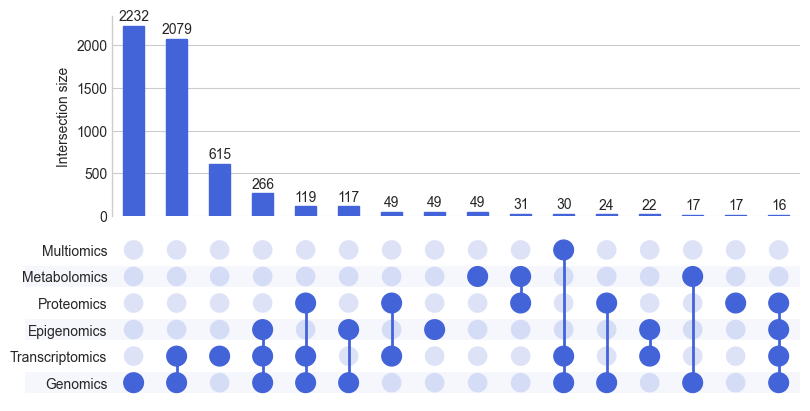

In [14]:
# Calculate papers per category

# load raw collected data
with open("tables/yearly_ids.json", "r") as f:
    yearly_ids = json.load(f)

# add one category_to_ids_dict per year
yearly_category_to_ids_dicts = {}
for year in yearly_ids:
    # ? = allow a paper to be counted several times, one for each modality
    category_to_ids_dict = {k: set(v) for k, v in yearly_ids[year].items()}

    # remove non-article pmids
    for v in category_to_ids_dict.values():
        v.difference_update(bad_article_pmids)
        
    yearly_category_to_ids_dicts[year] = category_to_ids_dict

# Combine counts per years into one total count
total_category_to_ids_dict = {'Genomics': set(), 'Transcriptomics': set(), 'Epigenomics': set(), 
                              'Proteomics': set(), 'Metabolomics': set(), 'Multiomics': set()}
for dict in yearly_category_to_ids_dicts.values():
    for category, ids in dict.items():
        total_category_to_ids_dict[category].update(ids)

# make plot
total_category_to_ids_dict = {k: list(v) for k, v in total_category_to_ids_dict.items()}
categories = from_contents(total_category_to_ids_dict)

fig = plt.figure(figsize=(10, 5))

ax_dict = UpSet(categories, 
                include_empty_subsets=False, 
                intersection_plot_elements=7,
                subset_size="count", 
                sort_by="cardinality", 
                min_subset_size=16,
                facecolor="#4363d8", 
                element_size=None, 
                totals_plot_elements = 0,
                show_counts = True
                )

fig = ax_dict.plot(fig)
# plt.suptitle('Combinations of omics used in publications in pediatric ALL during 2000-2025', fontsize=10)

# Save plot
save_path='figures/upset_plot.svg' # change to png or pdf if needed
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Upset plot saved to '{save_path}'")

## Line plot: categories vs years

✓ Line plot saved to 'figures/line_plot_categories.svg'


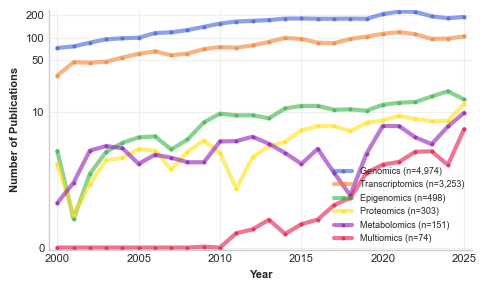

In [28]:
# Calculate papers per category

# load raw collected data
with open("tables/yearly_ids.json", "r") as f:
    yearly_ids = json.load(f)

yearly_category_to_ids_dicts = {}
yearly_counts = defaultdict(lambda: defaultdict(int))

for year in yearly_ids:

    # ? = give each category a fraction of a paper depending on how many modalities it has",
    category_to_ids_dict = {k: set(v) for k, v in yearly_ids[year].items()}

    # remove non-article pmids
    for v in category_to_ids_dict.values():
        v.difference_update(bad_article_pmids)
        
    yearly_category_to_ids_dicts[year] = category_to_ids_dict

    id_counts = Counter(x for s in category_to_ids_dict.values() for x in s)
    duplicate_ids = {x for x, c in id_counts.items() if c > 1}

    # make a reversed dict of duplicated ids to list of categories
    id_to_category_dict = defaultdict(list)
    for category, ids in category_to_ids_dict.items():
        for id in ids:
            id_to_category_dict[id].append(category)

    # sum up papers for each category for this year - use FRACTIONS OF A PAPER'S WORTH per category
    sum_per_category = {k: 0 for k in list(category_to_ids_dict.keys())}
    for id, categories in id_to_category_dict.items():
        n_modalities = len(categories)
        modality_fraction = 1/n_modalities
        for category in categories:
            sum_per_category[category] += modality_fraction

    # Add counts to yearly
    for category, summed_count in sum_per_category.items():
        yearly_counts[year][category] = int(summed_count)

# collect true numbers without fractions to display on legend
totals_per_category_withdups = {k: set() for k in list(category_to_ids_dict.keys())}
for dict in yearly_category_to_ids_dicts.values():
    for category, ids in dict.items():
        totals_per_category_withdups[category].update(ids)
sum_per_category_withdups = {k: len(v) for k, v in list(totals_per_category_withdups.items())}

yearly_df = pd.DataFrame(yearly_counts).T.fillna(0)

# Create a clean line plot showing trends over time

fig, ax = plt.subplots(figsize=(5, 3))

# Get custom colors
colors = create_custom_palette_1(len(yearly_df.columns))

# Sort categories by total publications (descending)
category_totals = yearly_df.sum().sort_values(ascending=False)

# Plot lines
for i, (category, color) in enumerate(zip(category_totals.index, colors)):
    values = yearly_df[category].values

    # smooth the lines
    values = savgol_filter(values, window_length=7, polyorder=5)
    values = [max(0, x) for x in values]

    ax.plot(yearly_df.index, values, 
            color=color, linewidth=3, 
            marker='o', markersize=2, 
            label=f'{category} (n={sum_per_category_withdups[category]:,})', 
            alpha=0.6)


# Customize the plot
ax.set_xlabel('Year', fontsize=8, fontweight='bold')
ax.set_ylabel('Number of Publications', fontsize=8, fontweight='bold')
# ax.set_title('Publication trends over time in pediatric ALL by omics category', 
#                 fontsize=10, 
#                 # fontweight='bold', 
#                 pad=10)

# Add legend
ax.legend(bbox_to_anchor=(0.655, 0.38), loc='upper left', fontsize=6.5)

# Customize grid and spines
ax.margins(x=0.02)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis to show every few years
ax.set_xticks([str(i) for i in range(2000, 2026, 5)])
plt.tick_params(axis='both', labelsize=8)

# Set log-scale on y-axis
ax.set_yscale('symlog')
ax.set_ylim(bottom=-0.05) 
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0, 10, 50, 100, 200])

# Adjust layout
plt.tight_layout()

# Save the plot
save_path='figures/line_plot_categories.svg'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Line plot saved to '{save_path}'")


## Line plot: number of categories vs years

✓ Line plot saved to 'figures/line_plot_number_of_omics.svg'


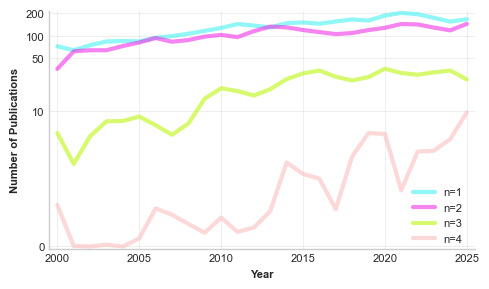

In [ ]:
# Calculate papers per category

# load raw collected data
with open("tables/yearly_ids.json", "r") as f:
    yearly_ids = json.load(f)

yearly_counts = defaultdict(lambda: defaultdict(int))

for year in yearly_ids:
    # ? = "n papers with x number modaities" instead of "n papers per specific modality"n",
    # ? categories = modality n (= 1-6)n",
    category_to_ids_dict = {k: set(v) for k, v in yearly_ids[year].items()}

    # remove non-article pmids
    for v in category_to_ids_dict.values():
        v.difference_update(bad_article_pmids)

    id_counts = Counter(x for s in category_to_ids_dict.values() for x in s)
    n_categories_to_ids_dict = {i: {k for k, v in id_counts.items() if v == i} for i in range(1, 7)}
    category_to_ids_dict = n_categories_to_ids_dict
    
    # after category distribution, add counts to yearly    
    for category, ids in category_to_ids_dict.items():
        yearly_counts[year][category] = len(ids)

# Create yearly DataFrame
yearly_df = pd.DataFrame(yearly_counts).T.fillna(0)
yearly_df = yearly_df.sort_index()  # Sort by year

# remove 5 and 6 categories from plot
yearly_df = yearly_df.iloc[:, :-2]

# Create a clean line plot showing trends over time

fig, ax = plt.subplots(figsize=(5, 3))

# Get custom colors
colors = create_custom_palette_2(len(yearly_df.columns))

# Sort categories by total publications (descending)
category_totals = yearly_df.sum().sort_values(ascending=False)

# Plot lines
for i, (category, color) in enumerate(zip(category_totals.index, colors)):
    values = yearly_df[category].values

    # smooth the lines
    values = savgol_filter(values, window_length=7, polyorder=5)
    values = [max(0, x) for x in values]

    ax.plot(yearly_df.index, values, 
            color=color, linewidth=3, 
            label=f'n={category}', 
            alpha=0.6)

# Customize the plot
ax.set_xlabel('Year', fontsize=8, fontweight='bold')
ax.set_ylabel('Number of Publications', fontsize=8, fontweight='bold')
# ax.set_title('Number of omics included per publication over time in pediatric ALL', 
#                 fontsize=10, 
#                 # fontweight='bold', 
#                 pad=20)

# Add legend
ax.legend(bbox_to_anchor=(0.83, 0.3), loc='upper left', fontsize=8)

# Customize grid and spines
ax.margins(x=0.02)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set x-axis to show every few years
ax.set_xticks([str(i) for i in range(2000, 2026, 5)])
plt.tick_params(axis='both', labelsize=8)

# Set log-scale on y-axis
ax.set_yscale('symlog')
ax.set_ylim(bottom=-0.05) 
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.set_yticks([0, 10, 50, 100, 200])

# Adjust layout
plt.tight_layout()

# Save the plot
save_path='figures/line_plot_number_of_omics.svg'
plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
print(f"✓ Line plot saved to '{save_path}'")
